In [3]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys
import seaborn as sns
import nbimporter
from read_plot_voxelization import  export_filtered_las, show_voxelgrid_plotly

### Detailed analysis with graphs

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_df_columns(cols, df):
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(cols):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True, bins=50, color='steelblue')
        plt.title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()

In [5]:
las_path = "../2025-07-15-LIDAR-Maslina2.las"

In [6]:
def las_to_dataframe(las_path: str) -> pd.DataFrame:
   
    las = laspy.read(las_path)

    dims = [dim.name for dim in las.point_format.dimensions]

    data = {}
    for dim in dims:
        try:
            arr = getattr(las, dim)
            data[dim] = np.array(arr)
        except AttributeError:
            continue

    df = pd.DataFrame(data)

    return df

In [7]:
las = laspy.read(las_path)

df = las_to_dataframe(las_path)
new_header = laspy.LasHeader(
    point_format=las.header.point_format.id,
    version=las.header.version
)

new_las = laspy.LasData(new_header)
    
print(f"Scale factors: {new_las.header.scales}")
print(f"Offsets: {new_las.header.offsets}")

Scale factors: [0.01 0.01 0.01]
Offsets: [0. 0. 0.]


In [8]:
z_min = df['Z'].min()
print(f"Minimal Z value (ground): {z_min:.3f}")

df['Z'] = df['Z'] - z_min
df['X'] = df['X'] / 100
df['Y'] = df['Y'] / 100
df['Z'] = df['Z'] / 100

print(f"New Z scope: {df['Z'].min():.2f} → {df['Z'].max():.2f}")

Minimal Z value (ground): 308.000
New Z scope: 0.00 → 40.88


In [9]:
print(df.columns.tolist())

print(df.head())
print(df.columns)

['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'distance', 'height above ground', 'beam id']
        X      Y     Z  intensity  return_number  number_of_returns  \
0  184.93 -32.60  2.15       2304              2                  2   
1  188.09 -33.37  2.71       1024              2                  2   
2  193.77 -34.72  1.24       1024              2                  2   
3  196.18 -35.31  2.51       2304              1                  1   
4  192.81 -61.30  2.82       1024              2                  2   

   synthetic  key_point  withheld  overlap  ...  scan_angle  point_source_id  \
0          0          0         0        0  ...        8437                3   
1          0          0         0        0  ...        8437                3   

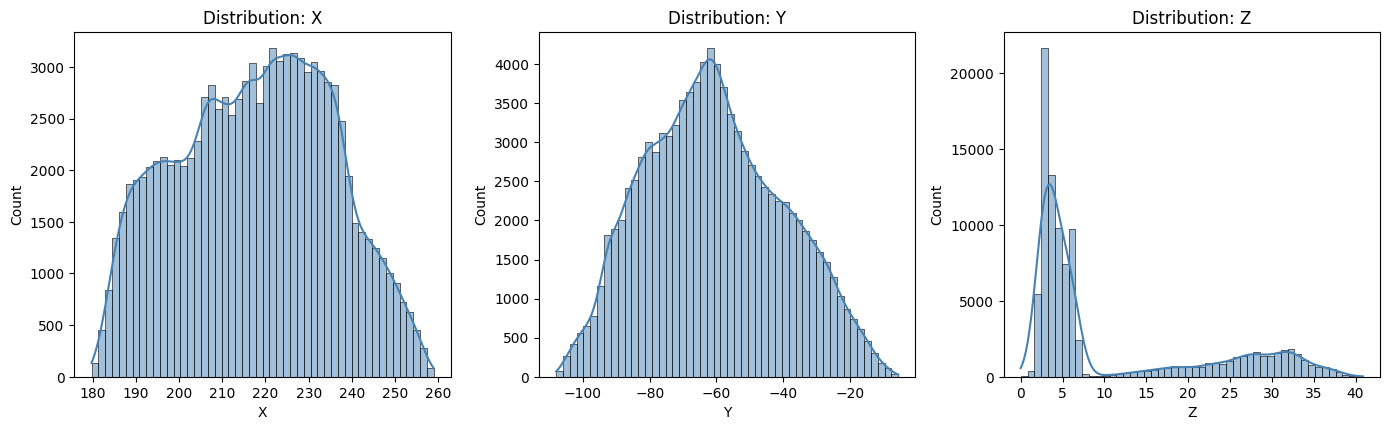

In [10]:
cols = ['X', 'Y', 'Z'] #, 'normal x', 'normal y', 'normal z'

plot_df_columns(cols, df)

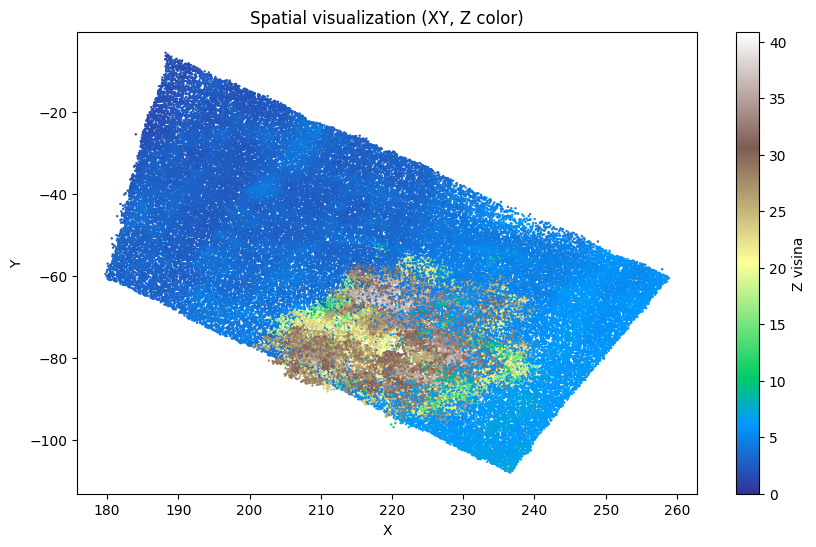

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(df['X'], df['Y'], s=0.5, c=df['Z'], cmap='terrain')
plt.colorbar(label='Z visina')
plt.title("Spatial visualization (XY, Z color)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [14]:
from read_plot_voxelization import plot_point_cloud_points

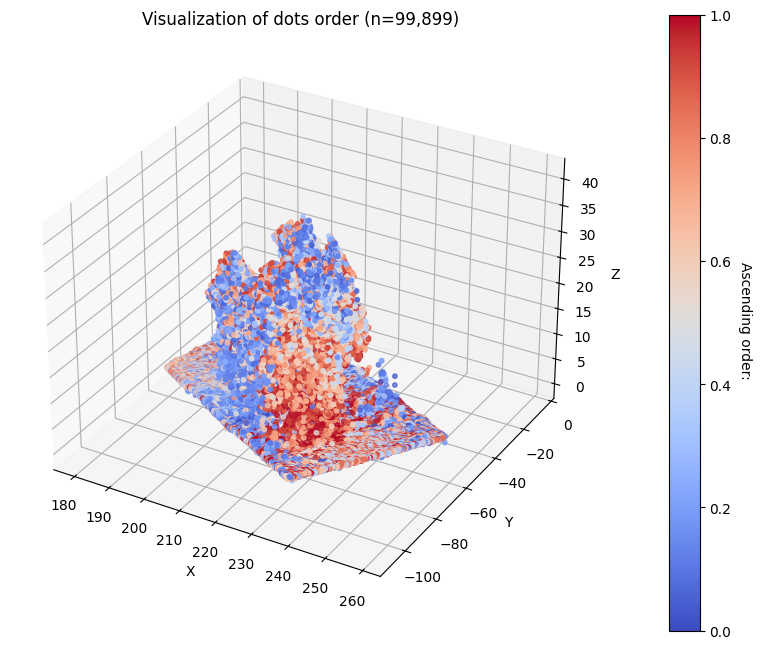

In [15]:
plot_point_cloud_points(df)

#### GROUND REMOVAL - RANSAC

In [16]:
import open3d as o3d
import numpy as np

def ransac_ground_removal(
    pcd,
    distance_threshold=2,
    ransac_n=3,
    num_iterations=3000,
    upright_axis=np.array([0, 0, 1]),
    max_tilt_deg=20
):
    """
    RANSAC ground segmentation on a 3D point cloud.

    pcd               : o3d.geometry.PointCloud
    distance_threshold: maximum distance from the plane to classify a point as ground (meters)
    ransac_n          : number of points used to fit the plane (3 for a plane)
    num_iterations    : number of RANSAC iterations
    upright_axis      : up-axis (default Z-axis)
    max_tilt_deg      : maximum plane tilt (in degrees) to still be considered ground
    """

    # 1) RANSAC plane segmentation
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=distance_threshold,
        ransac_n=ransac_n,
        num_iterations=num_iterations
    )

    a, b, c, d = plane_model
    normal = np.array([a, b, c], dtype=float)
    normal /= np.linalg.norm(normal)

    # 2) check if the detected plane has a valid "ground" orientation
    upright_axis = upright_axis.astype(float) / np.linalg.norm(upright_axis)
    cos_angle = np.abs(np.dot(normal, upright_axis))
    angle_deg = np.degrees(np.arccos(cos_angle))

    print(f"Plane model (a,b,c,d): {plane_model}")
    print(f"Plane normal: {normal}, tilt relative to {upright_axis}: {angle_deg:.2f}°")

    if angle_deg > max_tilt_deg:
        print("[WARNING] Detected plane is not horizontal enough — may not be ground.")

    # 3) separate ground and non-ground points
    ground_pcd = pcd.select_by_index(inliers)
    non_ground_pcd = pcd.select_by_index(inliers, invert=True)

    return ground_pcd, non_ground_pcd, plane_model


In [ ]:
xyz = np.vstack((las.x, las.y, las.z)).T.astype(np.float32)
rgb = np.vstack((las.red, las.green, las.blue)).transpose()/65535
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)￼
pcd.colors = o3d.utility.Vector3dVector(rgb)

In [18]:
ground_pcd, non_ground_pcd, plane_model = ransac_ground_removal(
    pcd,
    distance_threshold=0.05,  # adjust depending on scale / point density
    num_iterations=2000
)

print(ground_pcd, non_ground_pcd)

Plane model (a,b,c,d): [-3.39609448e-02  3.89734829e-02  9.98662967e-01 -1.86344518e+05]
Plane normal: [-0.03396094  0.03897348  0.99866297], tilt relative to [0. 0. 1.]: 2.96°
PointCloud with 50147 points. PointCloud with 49752 points.


In [19]:
import numpy as np
import pandas as pd
import open3d as o3d  

def pcd_to_df(pcd: o3d.geometry.PointCloud) -> pd.DataFrame:
    """
    Pretvara Open3D PointCloud u pandas DataFrame s kolonama x, y, z.
    Ako pcd nema nijednu točku, vraća prazan DataFrame.
    """
    points = np.asarray(pcd.points)
    if points.size == 0:
        return pd.DataFrame(columns=["X", "Y", "Z"])
    df = pd.DataFrame(points, columns=["X", "Y", "Z"])
    return df


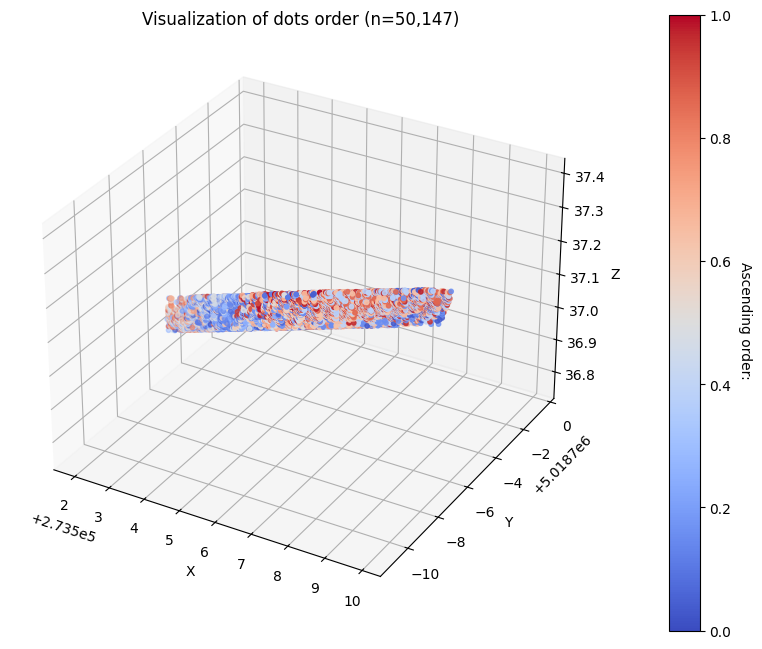

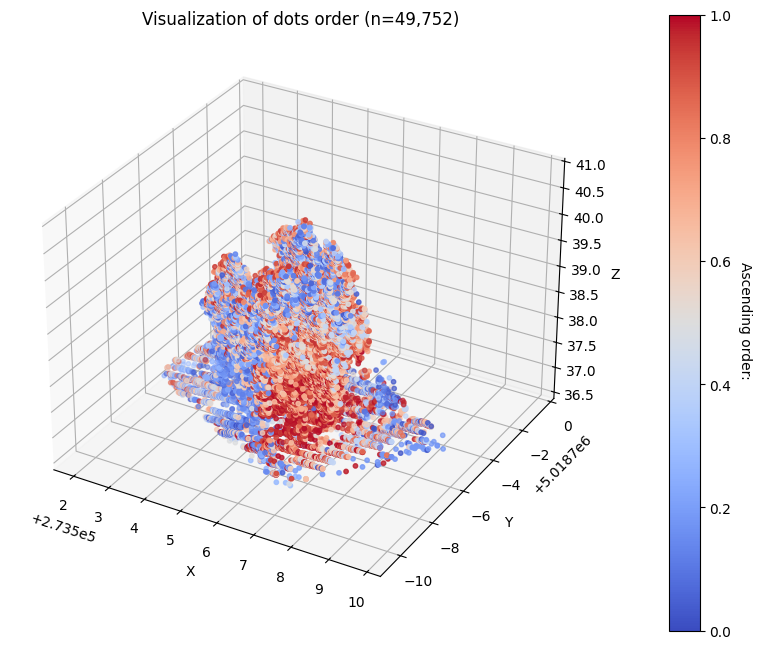

In [20]:
df_ground = pcd_to_df(ground_pcd)
df_non_ground = pcd_to_df(non_ground_pcd)

plot_point_cloud_points(df_ground)
plot_point_cloud_points(df_non_ground)

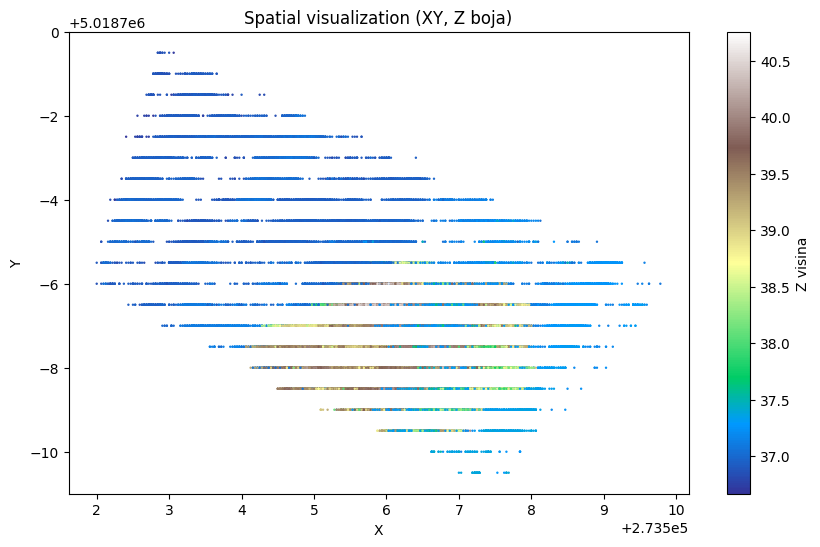

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(df_non_ground['X'], df_non_ground['Y'], s=0.5, c=df_non_ground['Z'], cmap='terrain')
plt.colorbar(label='Z visina')
plt.title("Spatial visualization (XY, Z boja)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


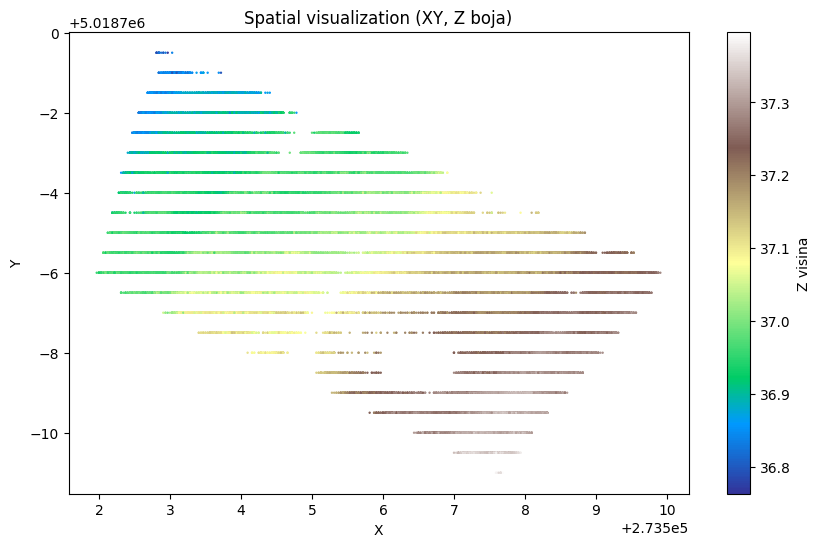

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(df_ground['X'], df_ground['Y'], s=0.5, c=df_ground['Z'], cmap='terrain')
plt.colorbar(label='Z visina')
plt.title("Spatial visualization (XY, Z boja)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [23]:
df = df[df['height above ground'] > 0.2]

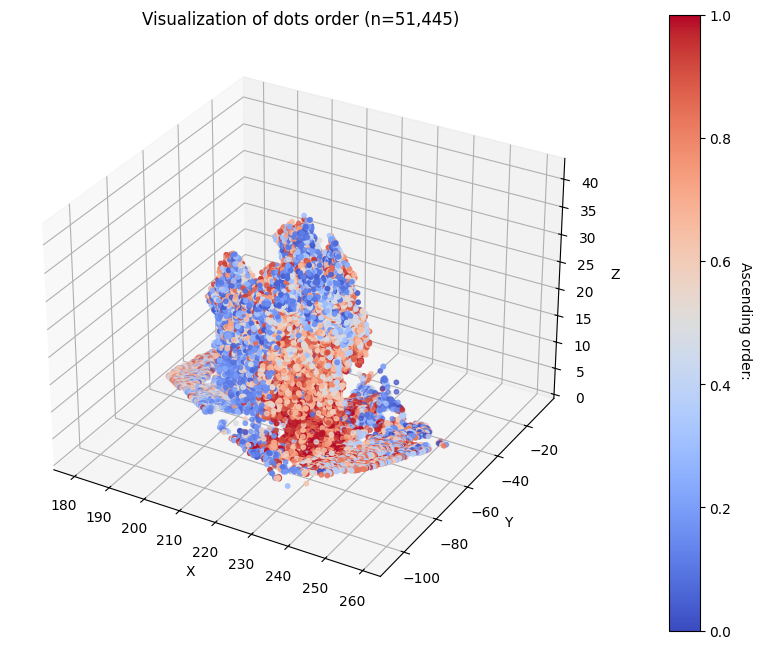

In [24]:
plot_point_cloud_points(df)

In [25]:
import numpy as np

def expand_ground_band(pcd, plane_model, max_dist=0.10):
    """
    Use the detected plane_model and classify as ground all points
    within max_dist from the plane.
    """
    points = np.asarray(pcd.points)
    a, b, c, d = plane_model
    normal = np.array([a, b, c], dtype=float)
    normal /= np.linalg.norm(normal)

    # point-to-plane distance: |a x + b y + c z + d|
    dist = np.abs(points @ normal + d)

    ground_idx = np.where(dist <= max_dist)[0]
    ground_pcd = pcd.select_by_index(ground_idx)
    non_ground_pcd = pcd.select_by_index(ground_idx, invert=True)

    return ground_pcd, non_ground_pcd

# 1) strict RANSAC to find a stable plane
_, _, plane_model = ransac_ground_removal(
    pcd,
    distance_threshold=0.03,
    num_iterations=2000
)

# 2) manually expand the ground band to ±10 cm
ground_pcd, non_ground_pcd = expand_ground_band(pcd, plane_model, max_dist=0.10)


Plane model (a,b,c,d): [-3.45187679e-02  3.91773452e-02  9.98635865e-01 -1.87215074e+05]
Plane normal: [-0.03451877  0.03917735  0.99863586], tilt relative to [0. 0. 1.]: 2.99°


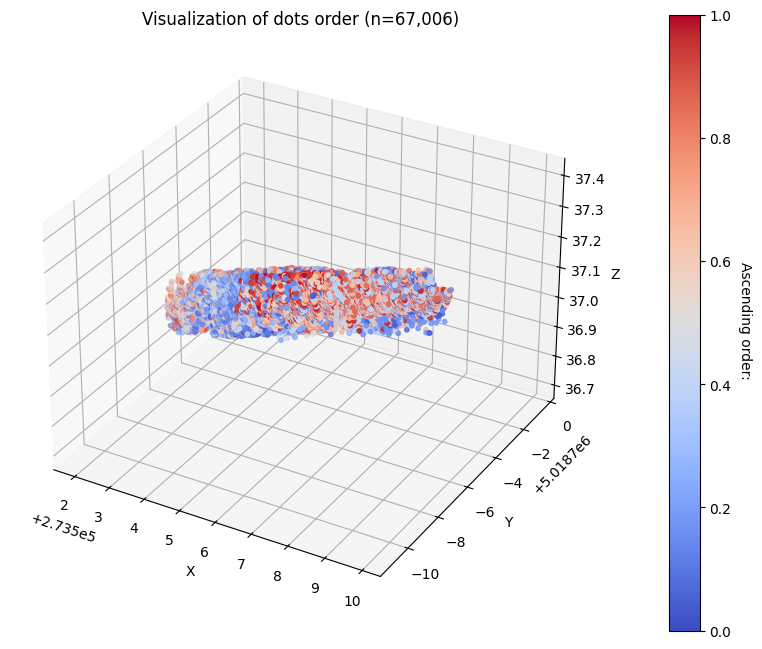

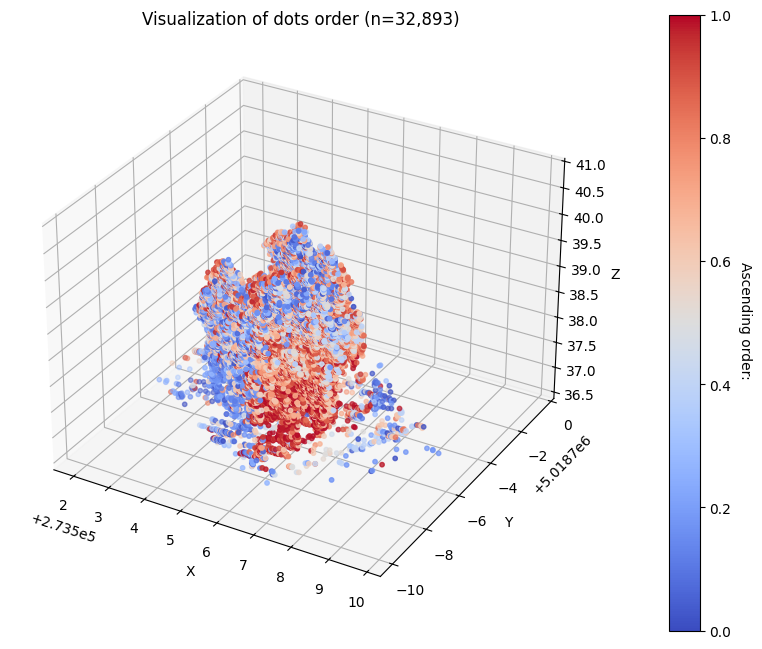

In [26]:
df_ground = pcd_to_df(ground_pcd)
df_non_ground = pcd_to_df(non_ground_pcd)

plot_point_cloud_points(df_ground)
plot_point_cloud_points(df_non_ground)